In [1]:
import pandas as pd
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
device=torch.device("mps")

In [5]:
train_df = pd.read_csv("mnist_train.csv")
test_df = pd.read_csv("mnist_test.csv")

print(test_df.shape)

(10000, 785)


In [32]:
train_df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
X_train = train_df.iloc[:, 1:].values   # pixels
y_train = train_df.iloc[:, 0].values    # labels

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

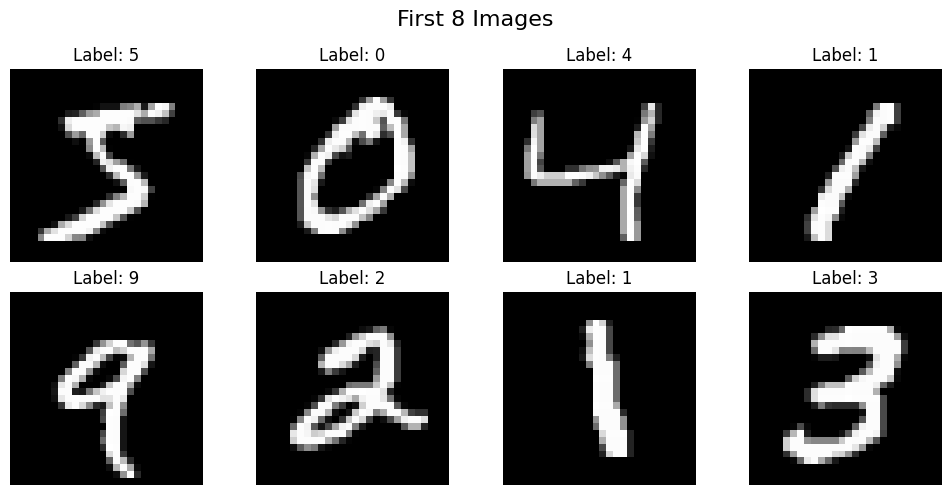

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
fig.suptitle("First 8 Images", fontsize=16)

for i, ax in enumerate(axes.flat):
    img = X_train[i].reshape(28, 28)

    ax.imshow(img, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Label: {y_train[i]}")

plt.tight_layout()
plt.show()

In [35]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
class CustomDataset(Dataset):

    def __init__(self,x,y):
        self.x=torch.tensor(x,dtype=torch.float32)
        self.y= torch.tensor(y,dtype=torch.long)

    def __len__(self):
        return len(self.x)
    
    def __getitem__(self,index):
        
        return self.x[index],self.y[index]


In [37]:
train_dataset= CustomDataset(X_train,y_train)

In [38]:
len(train_dataset)

60000

In [39]:
test_dataset= CustomDataset(X_test,y_test)

In [40]:
train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader= DataLoader(test_dataset,batch_size=64,shuffle=False)

In [41]:
len(train_loader)

938

In [ ]:
class MLP(nn.Module):

    def __init__(self, features):

        super().__init__()
        self.model=nn.Sequential(
            nn.Linear(features,128),
            #nn.BatchNorm1d(128)
            nn.ReLU(),
            #nn.Dropout(p=0.2)
            nn.Linear(128,64),
            ##nn.batchNorm1d(64)
            nn.ReLU(),
            #nn.Dropout(p=0.3)
            nn.Linear(64,10)

        )

    def forward(self,x):

        return self.model(x)






In [43]:
epochs=25
learning_rate=0.1

In [ ]:
model=MLP(X_train.shape[1])

model=model.to(device)

Loss= nn.CrossEntropyLoss()

optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4)





In [45]:
for epoch in range(epochs):

    total_epoch_loss=0
    

    for x_batch,y_batch in train_loader:
       
       # move data to gpu
       x_batch,y_batch=x_batch.to(device),y_batch.to(device)

        # forward pass
       out= model(x_batch)

       # calculate loss 

       loss=Loss(out,y_batch)

       # back pass
       optimizer.zero_grad()

       loss.backward()

       # update grads
       optimizer.step()

       total_epoch_loss=total_epoch_loss+loss.item()

    avg_loss=total_epoch_loss/len(train_loader)
    print(f'Epoch:{epoch+1}, Loss: {avg_loss}')





Epoch:1, Loss: 0.4899961408426258
Epoch:2, Loss: 0.1880072102165108
Epoch:3, Loss: 0.12895075918070034
Epoch:4, Loss: 0.09915579711970712
Epoch:5, Loss: 0.07979488191949421
Epoch:6, Loss: 0.06500197833489332
Epoch:7, Loss: 0.05443192767510528
Epoch:8, Loss: 0.04662562223317138
Epoch:9, Loss: 0.03934191450747703
Epoch:10, Loss: 0.03471006239691912
Epoch:11, Loss: 0.029842245845131076
Epoch:12, Loss: 0.025133735035607684
Epoch:13, Loss: 0.020809397433521046
Epoch:14, Loss: 0.017445691376375947
Epoch:15, Loss: 0.014888390193727842
Epoch:16, Loss: 0.01168107317128804
Epoch:17, Loss: 0.009504181157937447
Epoch:18, Loss: 0.008543430803573754
Epoch:19, Loss: 0.006893348336975122
Epoch:20, Loss: 0.005835347574670613
Epoch:21, Loss: 0.0047466150282648575
Epoch:22, Loss: 0.003677378821343007
Epoch:23, Loss: 0.0029635568102644853
Epoch:24, Loss: 0.0025716679791774927
Epoch:25, Loss: 0.002081439397753594


In [46]:
model.eval()

MLP(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [47]:
# Evaluation

total=0
correct=0

with torch.no_grad():

    for x_batch,y_batch in test_loader:

         # move data to gpu
        x_batch,y_batch=x_batch.to(device),y_batch.to(device)
       
        out=model(x_batch)

        _,predicted=torch.max(out,1)

        total=total+y_batch.shape[0]
        correct=correct+(predicted==y_batch).sum().item()

print(correct/total)


0.9823


In [48]:
len(test_loader)

157

In [49]:
total=0
correct=0

with torch.no_grad():

    for x_batch,y_batch in train_loader:

         # move data to gpu
        x_batch,y_batch=x_batch.to(device),y_batch.to(device)
       
        out=model(x_batch)

        _,predicted=torch.max(out,1)

        total=total+y_batch.shape[0]
        correct=correct+(predicted==y_batch).sum().item()

print(correct/total)

0.9999833333333333
